2026-07-01 15:13:02.737 | INFO     | __main__:audit_node:38 - 任务阶段已经全部执行完毕,诗已生成,笑话已生成


{'topic': '猫咪', 'poem': '## 《光的囚徒》\n\n你从午后三点的光里走来\n瞳孔切开时间的剖面\n以狐疑的步态丈量着\n地板与云朵的距离\n\n毛茸茸的尾巴卷起\n一缕炊烟 又轻轻放下\n每根胡须都是敏感的测针\n探测着客厅与宇宙的深浅\n\n窗台上的多肉植物\n正在练习缩骨术\n你却以优雅的懒腰\n把整个下午折叠成毛线球\n\n突然 你压低脊背\n埋伏于沙发投下的暗处\n所有的慵懒骤然收紧\n像弓弦 瞄准一个梦境\n\n扑向虚空的那一瞬\n爪子抓住了光的碎片\n却只捞起 自己\n尾巴尖上的 一小片月光\n\n躺在床单褶皱里\n你舔舐着前爪的印记\n整个房间都听见了\n那场无声猎杀的余音\n\n直到黄昏把你变成\n一团会打鼾的云朵\n呼吸的韵律 轻轻\n抚平时光所有褶皱', 'joke': '**笑话：**  \n为什么猫总是喜欢把桌上的陶瓷杯推下去？  \n——因为它们想测试“猫有九条命”是不是真的，而杯子只有一条命。'}


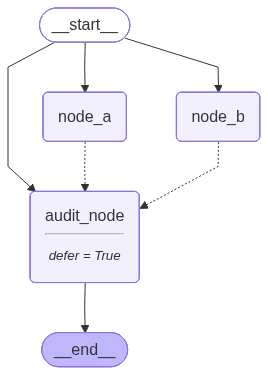

In [1]:
from typing import TypedDict,Literal
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from loguru import logger
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thingking":{
            "type":"disabled"
        }
    }
)

#1. 定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    content_type: str

#2. 定义节点
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([f"写一首关于{state['topic']}主题的诗"]).content
    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([f"写一个关于{state['topic']}主题的笑话"]).content
    return {
        "joke": joke
    }

def audit_node(state: OverAllState) -> OverAllState:
    logger.info(f"任务阶段已经全部执行完毕,诗{'已生成' if state['poem'] else '未生成'},笑话{'已生成' if state['joke'] else '未生成'}")



#3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a",node_a)
builder.add_node("node_b",node_b)
builder.add_node("audit_node",audit_node,defer=True)

builder.add_edge(START,"node_a")
builder.add_edge(START,"node_b")
builder.add_edge(START,"audit_node")
builder.add_edge("node_a",END)
builder.add_edge("node_b",END)
builder.add_edge("audit_node",END)

graph = builder.compile()
res = graph.invoke({"topic": "猫咪"})
print(res)


from IPython.display import display
display(graph)
